# Predicción de esquema de vacunación incompleto
### Selección estadística de variables + balanceo con SMOTENC

**Contexto breve**
- Objetivo: identificar con anticipación qué casos tienen mayor riesgo de quedarse con el esquema de vacunación infantil incompleto, para priorizar seguimiento.
- Enfoque: revisión de estabilidad temporal del objetivo, selección de variables con pruebas de hipótesis y corrección FDR, balanceo de clases con SMOTENC, comparación de modelos y optimización bayesiana de hiperparámetros.
- **El dataset de este notebook es sintético**, construido para replicar la estructura y el desbalance del problema original, sin usar ningún registro real de vacunación.
- Este es un proyecto operativo de salud pública (priorizar seguimiento), no un análisis sobre seguridad o eficacia de vacunas.
- Artículo completo: https://fuzzyfrog.ai/es/ai-lab/proyectos/salud/prediccion-esquema-vacunacion-incompleto-seleccion-estadistica/


## 0. Pipeline de la solución

- **Fuente**: registro de vacunación infantil con variables demográficas y administrativas
- **Objetivo**: esquema completo / incompleto (dosis registradas de cada vacuna)
- **Estabilidad temporal**: se revisa si la proporción de esquemas completos cambia mes a mes
- **Selección de variables**: pruebas de hipótesis (Mann-Whitney U, Chi-cuadrada) con corrección FDR
- **Balance de clases**: SMOTENC, para datos numéricos y categóricos mezclados
- **Modelos**: Regresión Logística, Random Forest, XGBoost
- **Optimización**: búsqueda bayesiana de hiperparámetros con Optuna sobre el modelo campeón
- **Salida**: riesgo estimado de esquema incompleto, para priorizar seguimiento

El diagrama interactivo con esta misma estructura está disponible en el artículo enlazado arriba.


## 1. Carga de datos

- Dataset sintético: `outputs/vacunacion_sintetico.csv`
- 1,500 registros sintéticos con variables demográficas y administrativas
- Clases desbalanceadas a propósito, para replicar el problema real


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('outputs/vacunacion_sintetico.csv')
print(f'El dataset (sintético) tiene {df.shape[0]} registros y {df.shape[1]} columnas.')
df.head(3)


El dataset (sintético) tiene 1500 registros y 12 columnas.


,edad_madre,num_hijos,distancia_centro_km,controles_prenatales,ingreso_hogar_idx,zona,nivel_educativo_madre,tipo_parto,region,mes_nacimiento,anio_nacimiento,target_norm
0,31,1,0.5,5,43,Urbana,Superior,Institucional,Region D,7,2022,True
1,25,1,4.1,2,42,Urbana,Ninguno,Institucional,Region D,8,2022,False
2,44,1,7.1,5,40,Rural,Superior,Institucional,Region A,5,2022,True


## 2. Explicación de los datos

- `distancia_centro_km`, `controles_prenatales`, `ingreso_hogar_idx`, `edad_madre`, `num_hijos`: variables numéricas
- `zona`, `nivel_educativo_madre`, `tipo_parto`, `region`: variables categóricas
- `mes_nacimiento`, `anio_nacimiento`: usadas para revisar estabilidad temporal del objetivo
- `target_norm`: `True` si el esquema de vacunación está completo, `False` si está incompleto (variable objetivo)


In [2]:
df['target_norm'].value_counts()


target_norm
True     1070
False     430
Name: count, dtype: int64

## 3. Análisis exploratorio (EDA)

- Estabilidad temporal del objetivo: proporción de esquemas completos por mes de nacimiento
- Relación entre distancia al centro de salud y esquema completo


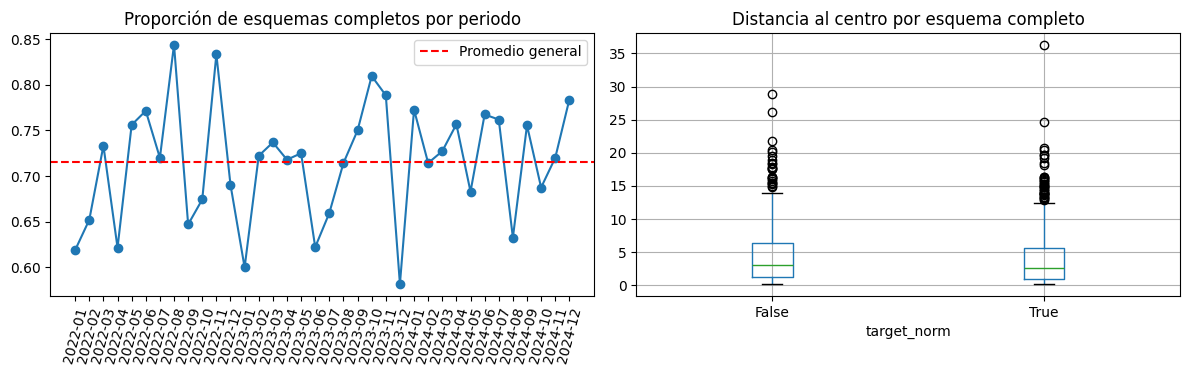

In [3]:
import matplotlib.pyplot as plt

df['periodo'] = df['anio_nacimiento'].astype(str) + '-' + df['mes_nacimiento'].astype(str).str.zfill(2)
estabilidad = df.groupby('periodo')['target_norm'].mean().sort_index()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(estabilidad.index, estabilidad.values, marker='o')
axs[0].set_title('Proporción de esquemas completos por periodo')
axs[0].tick_params(axis='x', rotation=75)
axs[0].axhline(estabilidad.mean(), color='red', linestyle='--', label='Promedio general')
axs[0].legend()

df.boxplot(column='distancia_centro_km', by='target_norm', ax=axs[1])
axs[1].set_title('Distancia al centro por esquema completo')
plt.suptitle('')

plt.tight_layout()
plt.show()


## 4. Modelado

- Selección de variables con Mann-Whitney U (numéricas) y Chi-cuadrada + Cramér's V (categóricas), corregidas con FDR
- Balance de clases con SMOTENC
- Comparación de 3 modelos y optimización bayesiana del campeón


In [4]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

target = 'target_norm'
num_cols = ['edad_madre', 'num_hijos', 'distancia_centro_km', 'controles_prenatales', 'ingreso_hogar_idx']
cat_cols = ['zona', 'nivel_educativo_madre', 'tipo_parto', 'region']

# Seleccion estadistica de variables numericas
resultados_num = []
for col in num_cols:
    g0 = df[df[target] == False][col].dropna()
    g1 = df[df[target] == True][col].dropna()
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    effect = abs((stat / (len(g0) * len(g1))) * 2 - 1)
    resultados_num.append({'variable': col, 'p_valor': p, 'effect_size': effect})

imp_num = pd.DataFrame(resultados_num)
_, p_adj, _, _ = multipletests(imp_num['p_valor'], method='fdr_bh')
imp_num['p_ajustado'] = p_adj
imp_num['significativo'] = imp_num['p_ajustado'] < 0.05
imp_num['score'] = -np.log10(imp_num['p_ajustado'].replace(0, 1e-300)) * imp_num['effect_size']
imp_num = imp_num.sort_values('score', ascending=False)

print('Variables numéricas, ordenadas por score (significancia x tamaño de efecto):')
imp_num


Variables numéricas, ordenadas por score (significancia x tamaño de efecto):


,variable,p_valor,effect_size,p_ajustado,significativo,score
3,controles_prenatales,1.117742e-07,0.174101,5.588711e-07,True,1.088601
4,ingreso_hogar_idx,3.920250e-04,0.116901,9.800625e-04,True,0.351724
2,distancia_centro_km,2.128043e-02,0.075927,3.546739e-02,True,0.110107
1,num_hijos,3.624180e-01,0.028516,4.530225e-01,False,0.009806
0,edad_madre,4.575728e-01,0.024466,4.575728e-01,False,0.008307


In [5]:
resultados_cat = []
for col in cat_cols:
    tabla = pd.crosstab(df[col], df[target])
    chi2, p, _, expected = stats.chi2_contingency(tabla)
    n = tabla.sum().sum()
    min_dim = min(tabla.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    resultados_cat.append({'variable': col, 'p_valor': p, 'effect_size': cramers_v})

imp_cat = pd.DataFrame(resultados_cat)
_, p_adj_cat, _, _ = multipletests(imp_cat['p_valor'], method='fdr_bh')
imp_cat['p_ajustado'] = p_adj_cat
imp_cat['significativo'] = imp_cat['p_ajustado'] < 0.05
imp_cat['score'] = -np.log10(imp_cat['p_ajustado'].replace(0, 1e-300)) * imp_cat['effect_size']
imp_cat = imp_cat.sort_values('score', ascending=False)

print('Variables categóricas, ordenadas por score:')
imp_cat


Variables categóricas, ordenadas por score:


,variable,p_valor,effect_size,p_ajustado,significativo,score
1,nivel_educativo_madre,0.000354,0.110929,0.000708,True,0.349444
0,zona,0.000122,0.099204,0.000488,True,0.328539
2,tipo_parto,0.056657,0.049211,0.075542,False,0.055206
3,region,0.776141,0.027128,0.776141,False,0.002986


In [6]:
from imblearn.over_sampling import SMOTENC, SMOTE
from sklearn.preprocessing import LabelEncoder

vars_top_num = imp_num[imp_num['significativo']]['variable'].tolist()
vars_top_cat = imp_cat[imp_cat['significativo']]['variable'].tolist()
vars_seleccionadas = vars_top_num + vars_top_cat

df_red = df[vars_seleccionadas + [target]].dropna().copy()
print(f'Variables seleccionadas ({len(vars_seleccionadas)}): {vars_seleccionadas}')

encoders = {}
for col in vars_top_cat:
    le = LabelEncoder()
    df_red[col] = le.fit_transform(df_red[col].astype(str))
    encoders[col] = le

X = df_red.drop(columns=[target])
y = df_red[target]
categorical_idx = [X.columns.get_loc(c) for c in vars_top_cat]

# SMOTENC necesita al menos una variable numerica y una categorica; si el barrido
# estadistico solo dejo un tipo, usamos SMOTE estandar como respaldo.
if len(categorical_idx) == 0 or len(categorical_idx) == X.shape[1]:
    print('Solo un tipo de variable resultó significativo: se usa SMOTE estándar como respaldo.')
    sampler = SMOTE(random_state=42, k_neighbors=5)
else:
    sampler = SMOTENC(categorical_features=categorical_idx, random_state=42, k_neighbors=5)

X_bal, y_bal = sampler.fit_resample(X, y)

print(f'Distribución original: {y.value_counts().to_dict()}')
print(f'Distribución balanceada: {pd.Series(y_bal).value_counts().to_dict()}')


Variables seleccionadas (5): ['controles_prenatales', 'ingreso_hogar_idx', 'distancia_centro_km', 'nivel_educativo_madre', 'zona']
Distribución original: {True: 1070, False: 430}
Distribución balanceada: {True: 1070, False: 1070}


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal)

modelos = {
    'Regresion Logistica': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
}

resultados_modelos = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    probs = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    resultados_modelos[nombre] = auc
    print(f'{nombre}: AUC = {auc:.3f}')


Regresion Logistica: AUC = 0.661


Random Forest: AUC = 0.818
XGBoost: AUC = 0.774


In [8]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 8),
        'class_weight': 'balanced',
        'random_state': 42,
    }
    modelo = RandomForestClassifier(**params)
    modelo.fit(X_train, y_train)
    probs = modelo.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, probs)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=False)

print(f'Mejor AUC tras optimización: {study.best_value:.3f}')
print(f'Mejores hiperparámetros: {study.best_params}')


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Mejor AUC tras optimización: 0.814
Mejores hiperparámetros: {'n_estimators': 167, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 1}


## 5. Evaluación

- Comparación de AUC entre los 3 modelos base y el modelo optimizado con Optuna
- Reporte de clasificación del modelo final


In [9]:
modelo_final = RandomForestClassifier(**study.best_params)
modelo_final.fit(X_train, y_train)
y_pred = modelo_final.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Incompleto', 'Completo']))
print(f'AUC final: {roc_auc_score(y_test, modelo_final.predict_proba(X_test)[:, 1]):.3f}')


              precision    recall  f1-score   support

  Incompleto       0.73      0.78      0.75       321
    Completo       0.76      0.72      0.74       321

    accuracy                           0.75       642
   macro avg       0.75      0.75      0.75       642
weighted avg       0.75      0.75      0.75       642

AUC final: 0.810


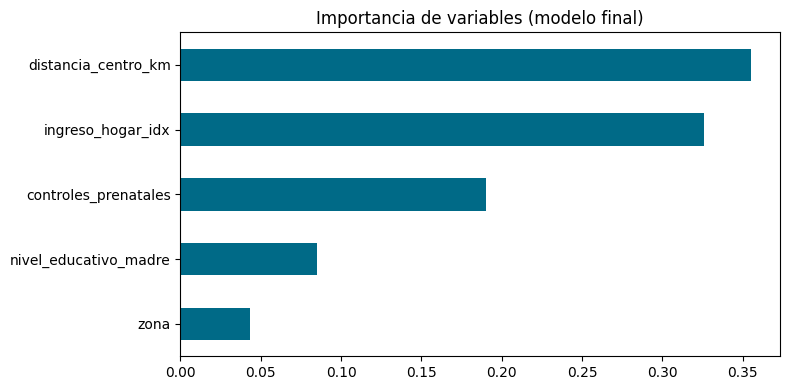

In [10]:
importancias = pd.Series(modelo_final.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importancias.plot(kind='barh', color='#006a87')
plt.title('Importancia de variables (modelo final)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Hallazgos principales

- La selección estadística de variables, con corrección FDR, dejó fuera columnas que un modelo de importancia hubiera considerado relevantes solo por correlación con otras ya seleccionadas.
- La proporción de esquemas completos varió entre periodos, lo que confirma que el modelo final debe interpretarse como un patrón general, no como una regla fija en el tiempo.
- SMOTENC permitió balancear las clases sin generar ejemplos sintéticos incoherentes en las variables categóricas.
- Este es un modelo de apoyo operativo para priorizar seguimiento, construido sobre datos sintéticos en este notebook; no debe interpretarse como una afirmación sobre vacunas en sí.

Artículo completo: https://fuzzyfrog.ai/es/ai-lab/proyectos/salud/prediccion-esquema-vacunacion-incompleto-seleccion-estadistica/
